In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("../data/raw/dataset.csv")

In [3]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (27375, 20)
<class 'pandas.DataFrame'>
RangeIndex: 27375 entries, 0 to 27374
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Name                 27375 non-null  str    
 1   contact_number       27375 non-null  int64  
 2   Contact_email        27375 non-null  str    
 3   creation_date        27375 non-null  str    
 4   first_call_attempt   20646 non-null  str    
 5   lead_status          27375 non-null  str    
 6   lead_stage           27375 non-null  str    
 7   lead_tag             15959 non-null  str    
 8   assigned_to          27375 non-null  str    
 9   last_call_date       20646 non-null  str    
 10  last_call_time       20646 non-null  str    
 11  references           0 non-null      float64
 12  campaign_name        27375 non-null  str    
 13  source_type          27375 non-null  str    
 14  source_name          27375 non-null  str    
 15  Total Leads         

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,27375,400,Anjali Chopra,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact_number,27375.0,NaN,NaN,NaN,7993885568.993352,1155797499.491386,6000026829.0,6991391931.5,7993050202.0,8996704892.5,9999843721.0
Contact_email,27375,27203,karthik.malhotra981@yahoo.com,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
creation_date,27375,20736,06-08-2025 22:00,4496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_call_attempt,20646,16137,21-07-2025 16:17,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lead_status,27375,6,CLOSED,12279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lead_stage,27375,4,LOST,11698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lead_tag,15959,7,not-interested,10869,NaN,NaN,NaN,NaN,NaN,NaN,NaN
assigned_to,27375,26,Anshad,9941,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_call_date,20646,15957,21-07-2025 16:17,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Missing Values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_df[missing_df["Missing Values"] > 0]

,Missing Values,Missing Percentage
references,27375,100.000000
lead_tag,11416,41.702283
first_call_attempt,6729,24.580822
last_call_date,6729,24.580822
last_call_time,6729,24.580822


In [ ]:
#duplicates
df.duplicated().sum()

np.int64(0)

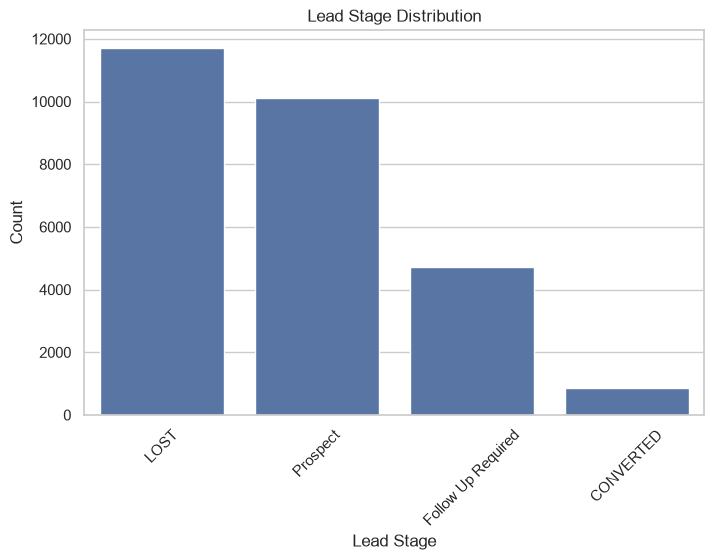

In [ ]:
#Lead Stage Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="lead_stage", order=df["lead_stage"].value_counts().index)
plt.title("Lead Stage Distribution")
plt.xlabel("Lead Stage")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Insight

This chart shows how leads are distributed across different stages such as Converted, Lost, Prospect, and Follow Up Required. A high number of lost or prospect leads may indicate opportunities to improve follow-up strategy and lead nurturing.

In [9]:
#Target Variable
df["lead_status"].value_counts()

lead_status
CLOSED                                   12279
PENDING WITH EXECUTIVE                    7947
NOT CONNECTED - RESCHEDULED BY SYSTEM     3857
RESCHEDULED BY EXECUTIVE                  2962
NOT CONNECTED - CLOSED BY SYSTEM           328
OPEN                                         2
Name: count, dtype: int64

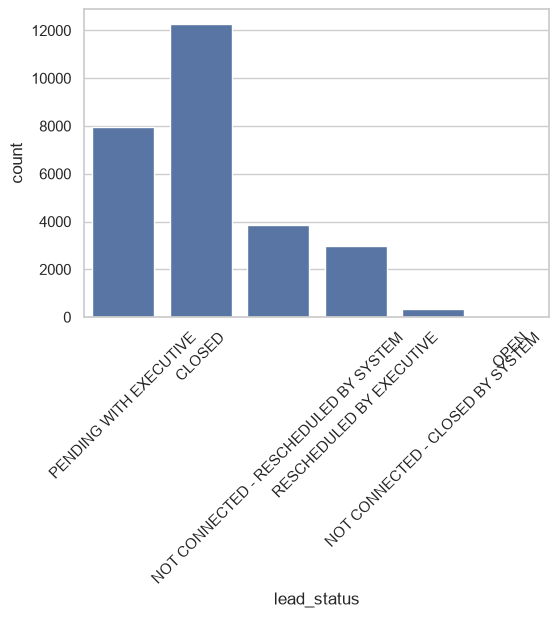

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="lead_status")

plt.xticks(rotation=45)
plt.show()

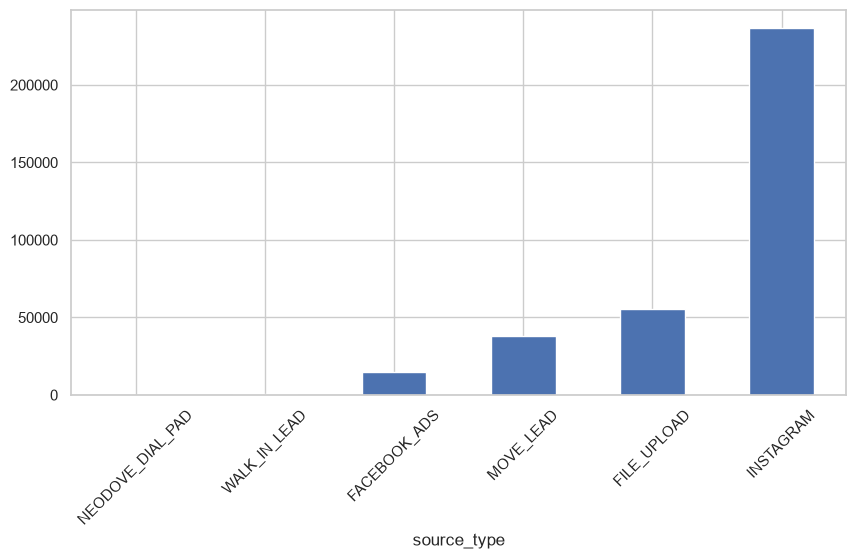

In [12]:
#Source Type Analysis
source_sales = df.groupby("source_type")["Sales"].sum().sort_values()
plt.figure(figsize=(10,5))

source_sales.plot(kind="bar")

plt.xticks(rotation=45)
plt.show()

<Axes: ylabel='campaign_name'>

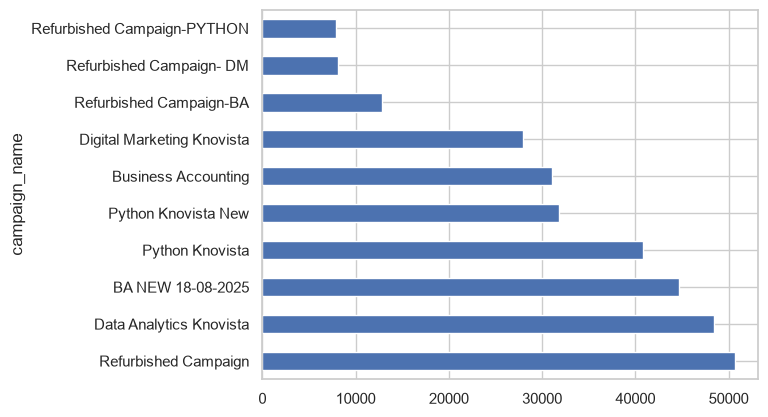

In [13]:
#Campaign Analysis
campaign = (df.groupby("campaign_name")["Sales"].sum().sort_values(ascending=False).head(10))
campaign.plot(kind="barh")

<Axes: xlabel='assigned_to'>

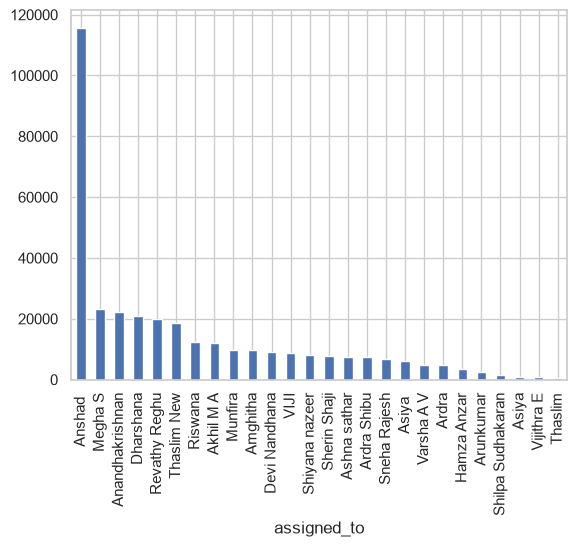

In [14]:
#Sales Executive Performance
executive = (df.groupby("assigned_to")["Sales"].sum().sort_values(ascending=False))
executive.plot(kind="bar")

<Axes: xlabel='creation_date', ylabel='Leads'>

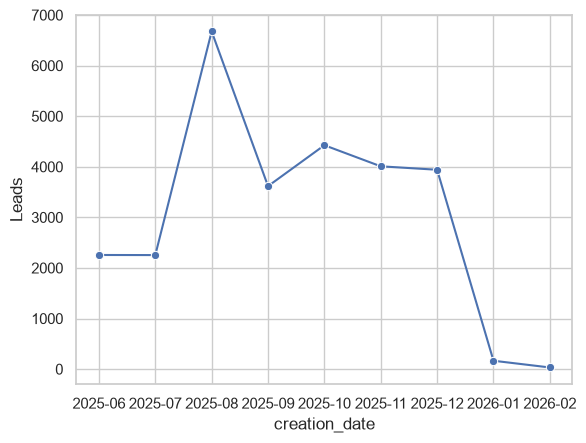

In [23]:
#Monthly Lead Creation Trend
df["creation_date"] = pd.to_datetime(df["creation_date"],format="%d-%m-%Y %H:%M")

monthly_leads = (
    df.groupby(df["creation_date"].dt.to_period("M"))
      .size()
      .reset_index(name="Leads")
)

monthly_leads["creation_date"] = monthly_leads["creation_date"].astype(str)

sns.lineplot(data=monthly_leads,
             x="creation_date",
             y="Leads",
             marker="o")

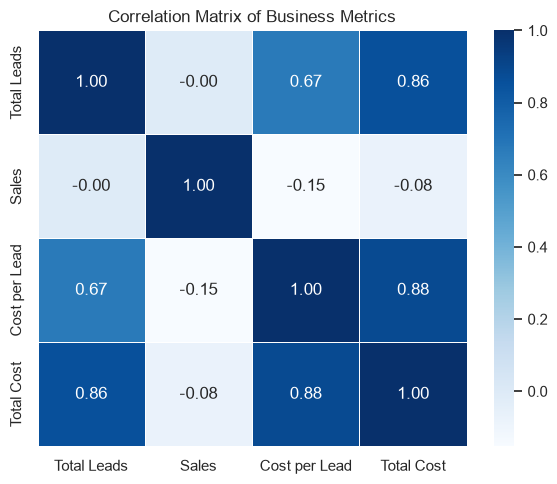

In [ ]:
#correlation

corr_cols = ['Total Leads', 'Sales','Cost per Lead', 'Total Cost']

# Compute correlation matrix
corr_matrix = df[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Business Metrics")
plt.tight_layout()
plt.show()

### Insights

Higher campaign spending is strongly associated with increased lead volume and acquisition costs. However, Sales shows little correlation with spending or lead volume, indicating that conversion effectiveness and lead quality are more important drivers of sales performance than investment alone.

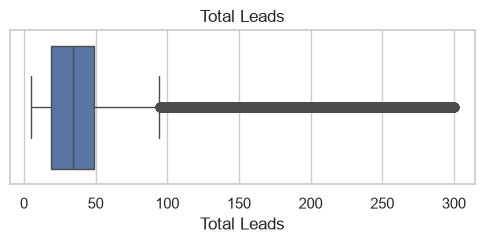

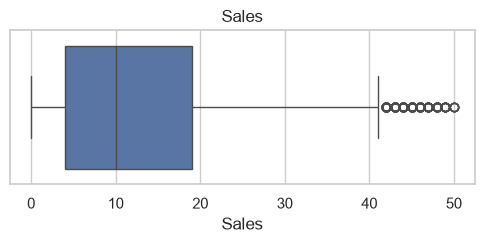

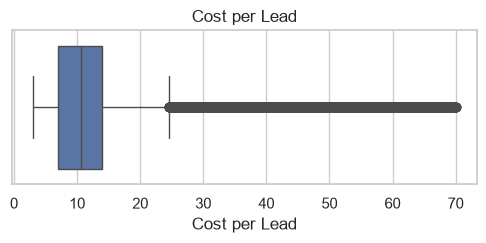

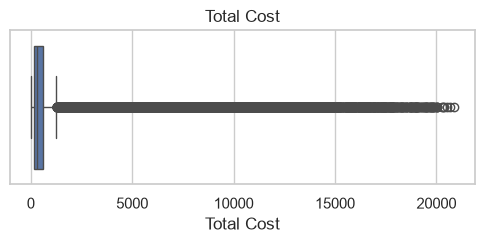

In [21]:
#Boxplots for outliers
for col in corr_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### Insight

The boxplots reveal that all four business metrics exhibit right-skewed distributions with the presence of high-value outliers. Sales and Total Cost contain several extreme observations beyond the upper whisker, while Total Leads and Cost per Lead also show a number of unusually high values. These outliers likely represent high-performing campaigns or exceptional business cases rather than data errors. Therefore, they should be carefully evaluated during preprocessing and retained only if they reflect genuine business scenarios.